# 2. Data Cleaning

Data cleaning prepares raw data for machine learning by fixing common quality issues.

In this notebook section covers:

1. Missing data detection and treatment  
2. Missing data patterns: MCAR, MAR, MNAR  
3. Outlier detection using IQR, Z-score, and Isolation Forest  
4. Outlier treatment using trimming, winsorization, and transformations  
5. Feature scaling using StandardScaler, MinMaxScaler, and RobustScaler  

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.ensemble import IsolationForest

In [2]:

# 1. Load Titanic Dataset from OpenML
print('Fetching Titanic dataset from OpenML...')
titanic = fetch_openml(name='titanic', version=1, as_frame=True, parser='auto')
titanic_df = titanic.frame

# 2. Load LendingClub Dataset via OpenML
print('Fetching LendingClub dataset from OpenML...')
# Using a common OpenML version of lending club
lending = fetch_openml(name='lending-club-loan-data', version=1, as_frame=True, parser='auto')
lending_df = lending.frame

print('Datasets loaded successfully!')

Fetching Titanic dataset from OpenML...
Fetching LendingClub dataset from OpenML...
Datasets loaded successfully!


### Missing Data Detection

Missing data can be detected using:

- `.isnull()`
- `.isnull().sum()`
- Missing-value heatmaps

Missing data strategy depends on the pattern:

- **MCAR**: Missing Completely at Random
- **MAR**: Missing at Random
- **MNAR**: Missing Not at Random

If missingness itself contains signal, we can add a missing indicator column.

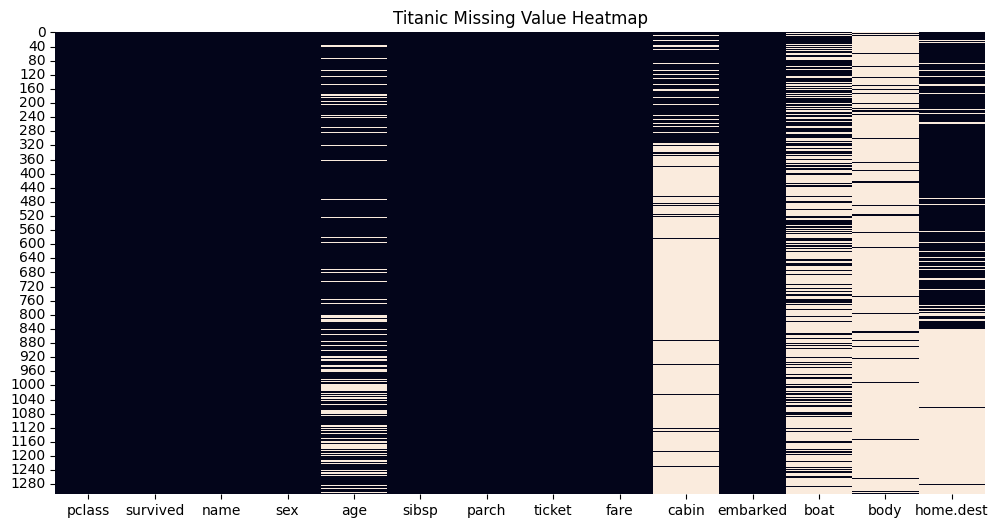

In [3]:
# Missing value heatmap for Titanic

plt.figure(figsize=(12, 6))
sns.heatmap(titanic_df.isnull(), cbar=False)
plt.title("Titanic Missing Value Heatmap")
plt.show()

### Missing Indicators

A missing indicator is a binary column showing whether a value was originally missing.

This is useful when missingness may carry information.  
For example, in Titanic, missing age may be related to passenger group, class, or survival.

,age,age_missing,survived
0,29.0000,0,1
1,0.9167,0,1
2,2.0000,0,0
3,30.0000,0,0
4,25.0000,0,0
5,48.0000,0,1
6,63.0000,0,1
7,39.0000,0,0
8,53.0000,0,1
9,71.0000,0,0


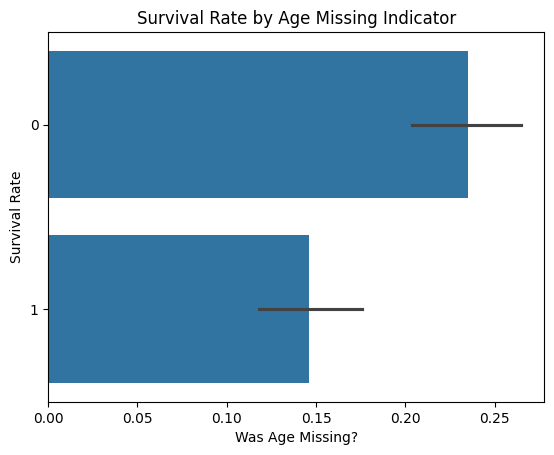

In [4]:
# Add missing indicator for Titanic age

titanic_df["age_missing"] = titanic_df["age"].isnull().astype(int)

display(titanic_df[["age", "age_missing", "survived"]].head(10))

sns.barplot(data=titanic_df, x="age_missing", y="survived")
plt.title("Survival Rate by Age Missing Indicator")
plt.xlabel("Was Age Missing?")
plt.ylabel("Survival Rate")
plt.show()

### Handling Missing Data

Common approaches:

1. **Remove rows or columns**
2. **Simple imputation**
3. **Advanced imputation**
4. **Model-based handling**


In [5]:
# Create a working copy

titanic_clean = titanic_df.copy()

# Numeric and categorical columns
numeric_cols = titanic_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = titanic_clean.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'body', 'age_missing']
Categorical columns: ['survived', 'name', 'sex', 'ticket', 'cabin', 'embarked', 'boat', 'home.dest']


C:\Users\samik\AppData\Local\Temp\ipykernel_3076\1165905746.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = titanic_clean.select_dtypes(include=["object", "category"]).columns.tolist()


In [6]:
# Simple imputation example

# Median imputation for numeric columns
num_imputer = SimpleImputer(strategy="median")
titanic_clean[numeric_cols] = num_imputer.fit_transform(titanic_clean[numeric_cols])

# Mode imputation for categorical columns
cat_imputer = SimpleImputer(strategy="most_frequent")
titanic_clean[categorical_cols] = cat_imputer.fit_transform(titanic_clean[categorical_cols])

print("Missing values after imputation:")
display(titanic_clean.isnull().sum().sort_values(ascending=False).head(10))

Missing values after imputation:


pclass      0
survived    0
name        0
sex         0
age         0
sibsp       0
parch       0
ticket      0
fare        0
cabin       0
dtype: int64

### KNN Imputation

KNN imputation fills missing values using similar rows.

This can work well when nearby observations have similar feature values, but it is slower than simple imputation and is sensitive to scaling.

In [ ]:
# KNN imputation example on selected Titanic numeric columns

knn_cols = ["age", "fare", "sibsp", "parch"]

titanic_knn = titanic_df[knn_cols].copy()

knn_imputer = KNNImputer(n_neighbors=5)
titanic_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(titanic_knn),
    columns=knn_cols
)
# Get indices of rows where age is missing
missing_age_indices = titanic_knn[titanic_knn['age'].isnull()].index

# Display original rows with missing age
display(titanic_knn.loc[missing_age_indices].head())

# Display imputed rows for the same indices
display(titanic_knn_imputed.loc[missing_age_indices].head())

,age,fare,sibsp,parch
15,NaN,25.9250,0,0
37,NaN,26.5500,0,0
40,NaN,39.6000,0,0
46,NaN,31.0000,0,0
59,NaN,27.7208,0,0


,age,fare,sibsp,parch
0,29.0000,211.3375,0.0,0.0
1,0.9167,151.5500,1.0,2.0
2,2.0000,151.5500,1.0,2.0
3,30.0000,151.5500,1.0,2.0
4,25.0000,151.5500,1.0,2.0
